# Swarm Data Analysis

## Datasets

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")

optimized = pd.read_csv("swarm_foraging_experiment_optimized_20260507_053031.csv")
hypothesis = pd.read_csv("swarm_foraging_experiment_hypothesized_20260507_053031.csv")

cols_to_drop = [
    "iteration", "width", "height", "n_food_clusters", 
    "food_area_percentage", "food_base_quantity", "num_agents", 
    "pheromone_decay_rate", "safety_buffer_steps", "foraging_start_threshold", 
    "pheromone_memory_weight", "pheromone_base_drop", "pheromone_follow_prob", "seed"
]

optimized = optimized.drop(columns=cols_to_drop, errors='ignore')
hypothesis = hypothesis.drop(columns=cols_to_drop, errors='ignore')

display(optimized.head())
display(hypothesis.head())

C:\Users\tasio\AppData\Local\Temp\ipykernel_30840\3770642496.py:9: DtypeWarning: Columns (0: Has Food) have mixed types. Specify dtype option on import or set low_memory=False.
  optimized = pd.read_csv("swarm_foraging_experiment_optimized_20260507_053031.csv")


,RunId,Step,Foraging,Returning,Resting,Alive,Dead (Energy),Dead (Temperature),Deaths Foraging (Energy),Deaths Foraging (Temperature),...,Mean Distance to Nest,Mean Lifetime Food Collected,AgentID,Energy,Temperature,State,Distance_to_Nest,Age,Lifetime Food Collected,Has Food
0,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,1.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
1,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,2.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
2,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,3.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
3,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,4.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
4,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,5.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False


,RunId,Step,Foraging,Returning,Resting,Alive,Dead (Energy),Dead (Temperature),Deaths Foraging (Energy),Deaths Foraging (Temperature),...,Mean Distance to Nest,Mean Lifetime Food Collected,AgentID,Energy,Temperature,State,Distance_to_Nest,Age,Lifetime Food Collected,Has Food
0,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,1.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
1,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,2.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
2,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,3.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
3,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,4.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False
4,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,5.0,1000.0,30.0,FORAGING,0.0,0.0,0.0,False


In [2]:
def process_swarm_data(df, name):
    print(f"--- Processing Dataset: {name} ---")
    step_keys = ["RunId", "Step"] 
    
    step_df = (
        df.drop_duplicates(step_keys)
        .sort_values(step_keys)
        .copy()
        .reset_index(drop=True)
    )
    step_df["Step"] = step_df["Step"].astype(int)

    # Final State of each Run
    run_df = step_df.groupby("RunId", as_index=False).tail(1).copy().reset_index(drop=True)
    run_df["completed_steps"] = run_df["Step"] + 1
    
    # Food ratio 
    run_df["food_collection_ratio"] = run_df["Total Food Collected"] / (
        run_df["Total Food Collected"] + run_df["Remaining Food (Units)"].clip(lower=1.0)
    )

    rows_per_run = df.groupby("RunId").size().rename("rows")
    steps_per_run = step_df.groupby("RunId")["Step"].nunique().rename("unique_steps")
    
    cols_to_keep = [
        "RunId", "completed_steps", "Alive", "Dead (Energy)", "Dead (Temperature)",
        "Total Food Collected", "Remaining Food (Units)", "Resource Retrieval Rate",
        "Load Gini", "Cumulative Thermal Load", "Shannon Entropy", "Thermal Efficiency",
        "Mean Agent Energy", "Mean Agent Temperature", "Mean Distance to Nest",
        "Mean Lifetime Food Collected"
    ]
    
    run_summary = (
        run_df[[c for c in cols_to_keep if c in run_df.columns]]
        .merge(rows_per_run, on="RunId")
        .merge(steps_per_run, on="RunId")
        .sort_values("RunId")
        .reset_index(drop=True)
    )

    print(f"- Runs represented: {run_summary['RunId'].nunique():,}")
    print(f"- Mean completed steps: {run_summary['completed_steps'].mean():,.2f}")
    print()

    stats_cols = ["completed_steps", "Total Food Collected", "Resource Retrieval Rate", "Load Gini", "Thermal Efficiency", "Shannon Entropy"]
    summary_stats = run_summary[[c for c in stats_cols if c in run_summary.columns]].describe().T
    
    display(summary_stats)
    return run_summary, summary_stats

optimized_summary, optimized_stats = process_swarm_data(optimized, "Optimized")
hypothesis_summary, hypothesis_stats = process_swarm_data(hypothesis, "Hypothesis")

--- Processing Dataset: Optimized ---
- Runs represented: 30
- Mean completed steps: 1,007.37



,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,1007.366667,507.373527,292.000000,577.750000,1024.000000,1281.500000,2564.000000
Total Food Collected,30.0,362.100000,295.151083,16.000000,117.500000,363.000000,530.250000,1364.000000
Resource Retrieval Rate,30.0,0.311712,0.143982,0.054983,0.209881,0.301643,0.414742,0.555856
Load Gini,30.0,0.378401,0.117929,0.168328,0.316366,0.359311,0.470266,0.646875
Thermal Efficiency,30.0,0.002248,0.001665,0.000133,0.000912,0.002064,0.003146,0.008133
Shannon Entropy,30.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


--- Processing Dataset: Hypothesis ---
- Runs represented: 30
- Mean completed steps: 361.50



,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,361.500000,167.683764,202.000000,233.250000,293.000000,428.500000,818.000000
Total Food Collected,30.0,227.566667,280.465830,9.000000,19.000000,129.500000,302.250000,1143.000000
Resource Retrieval Rate,30.0,0.482305,0.389208,0.038961,0.093231,0.464792,0.712700,1.572215
Load Gini,30.0,0.398314,0.233225,0.102345,0.198046,0.310523,0.662727,0.855556
Thermal Efficiency,30.0,0.001917,0.001990,0.000087,0.000216,0.001457,0.002689,0.008251
Shannon Entropy,30.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


As can be seen, the Optimized configuration prioritizes longevity over intensity, as shown by the mean completed_steps value of 1007.37, which is nearly three times higher than the Hypothesis group’s 361.50, indicating that the Optuna-tuned parameters, such as the foraging_start_threshold or safety_buffer_steps, were effective in preventing premature mass extinction and extending swarm survival.

An important contrast appears in the Resource Retrieval Rate. Although the Hypothesis group achieved a higher mean retrieval rate of 0.482 compared to 0.311 for the Optimized group, this does not necessarily indicate superior performance. Instead, it suggests a high-intensity “high-burn” strategy in which agents forage aggressively and collect resources rapidly, but at the cost of significantly shorter lifespans due to faster triggering of T_crit (thermal death). The Optimized group, by comparison, follows a slower and more sustainable strategy. While retrieval occurs at a lower rate, the swarm survives substantially longer and ultimately collects more total food overall (362.1 versus 227.5).

The Thermal Efficiency metric also supports this interpretation. The recorded values are numerically small (0.0022 for Optimized and 0.0019 for Hypothesis) because cumulative_thermal_load aggregates heat across all agents and simulation ticks, producing very large denominators. Despite the seemingly minor absolute difference of 0.0003, the relative improvement is approximately 17%. In the context of a biological or robotic swarm simulation where heat accumulation represents a hard survival constraint, this improvement is significant. It demonstrates that the Optimized swarm produces more useful work for each unit of thermal load generated.

Finally, the Shannon Entropy values of 0.0000 across all summaries are best interpreted as an artifact of the final-state analysis. Since the data was collected at the final simulation step, the swarm had already collapsed spatially, because agents had died. As a result, no meaningful spatial diversity remained at the time of recording. In contrast, the Load Gini values remain relatively stable across both groups, ranging from approximately 0.37 to 0.39, suggesting that the pheromone-following mechanism, governed by pheromone_follow_prob, produces a comparable level of task specialization and workload inequality in both configurations.

## Survival Analysis

--- Survival Analysis: Optimized ---
- Agents observed (total pool): 1,200
- Mean lifetime: 460.7 steps
- Median lifetime: 381.0 steps
- Min / max lifetime: 117 / 2,563 steps
- Kaplan-Meier median survival time: 381 steps
- Death causes by model counters: 94.8% energy, 5.2% temperature



,last_state,agents,percent
0,RETURNING,470,39.166667
1,RESTING,365,30.416667
2,FORAGING,365,30.416667




--- Survival Analysis: Hypothesis ---
- Agents observed (total pool): 1,500
- Mean lifetime: 214.7 steps
- Median lifetime: 182.0 steps
- Min / max lifetime: 109 / 817 steps
- Kaplan-Meier median survival time: 182 steps
- Death causes by model counters: 65.2% energy, 34.8% temperature



,last_state,agents,percent
0,RETURNING,1064,70.933333
1,FORAGING,227,15.133333
2,RESTING,209,13.933333


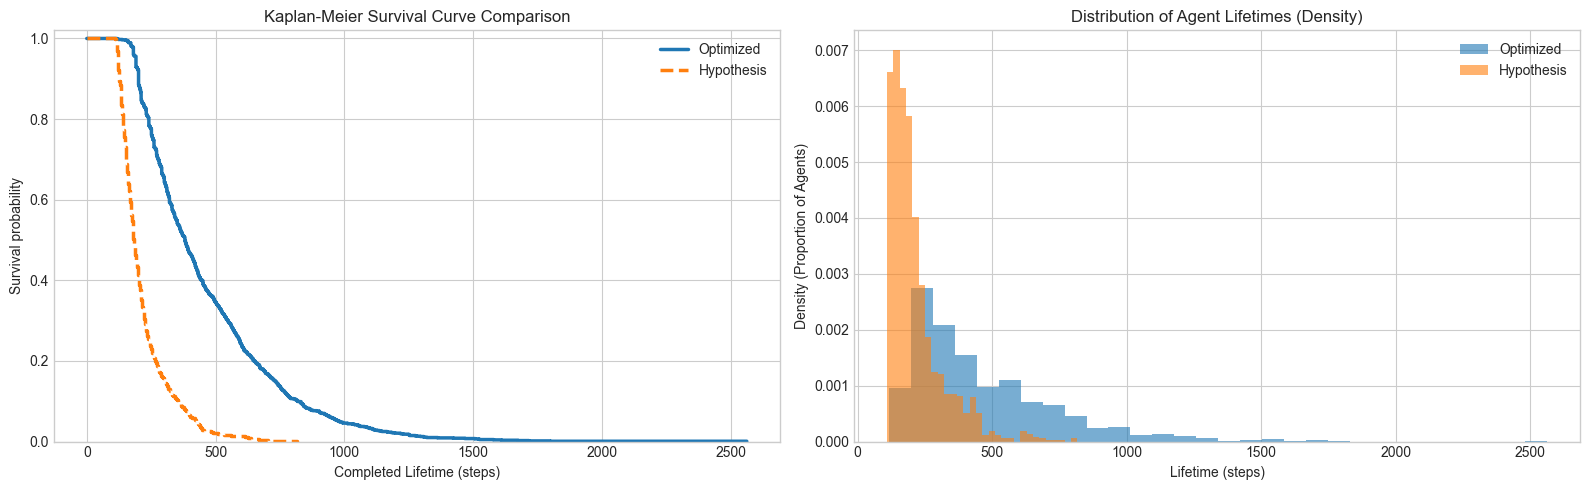

In [ ]:
def analyze_agent_survival(df, dataset_name):
    print(f"--- Survival Analysis: {dataset_name} ---")
    
    agent_last_index = df.groupby(["RunId", "AgentID"])['Step'].idxmax()
    last_agent_rows = df.loc[agent_last_index].copy().reset_index(drop=True)
    last_agent_rows["lifetime_steps"] = last_agent_rows["Step"].astype(int) + 1

    agent_lifetimes = last_agent_rows[["RunId", "AgentID", "lifetime_steps", "State", "Temperature", "Energy", "Has Food", "Distance_to_Nest"]].copy()

    life_counts = agent_lifetimes["lifetime_steps"].value_counts().sort_index()
    km_times = []
    km_survival = []
    n_at_risk = int(agent_lifetimes.shape[0])
    survival_probability = 1.0
    
    for time_step, event_count in life_counts.items():
        if n_at_risk <= 0:
            break
        survival_probability *= 1.0 - (event_count / n_at_risk)
        km_times.append(int(time_step))
        km_survival.append(float(survival_probability))
        n_at_risk -= int(event_count)

    km_curve = pd.DataFrame({"time": km_times, "survival_probability": km_survival})
    median_survival = next((time for time, survival in zip(km_times, km_survival) if survival <= 0.5), None)

    cause_counts = last_agent_rows["State"].value_counts().rename_axis("last_state").reset_index(name="agents")
    state_percent = cause_counts.copy()
    state_percent["percent"] = 100.0 * state_percent["agents"] / state_percent["agents"].sum()

    run_df = df.groupby("RunId").tail(1)
    final_death_summary = run_df[["Dead (Energy)", "Dead (Temperature)"]].sum()
    total_deaths = float(final_death_summary.sum())
    energy_share = 100.0 * final_death_summary["Dead (Energy)"] / max(total_deaths, 1.0)
    temp_share = 100.0 * final_death_summary["Dead (Temperature)"] / max(total_deaths, 1.0)

    print(f"- Agents observed (total pool): {len(agent_lifetimes):,}")
    print(f"- Mean lifetime: {agent_lifetimes['lifetime_steps'].mean():,.1f} steps")
    print(f"- Median lifetime: {agent_lifetimes['lifetime_steps'].median():,.1f} steps")
    print(f"- Min / max lifetime: {agent_lifetimes['lifetime_steps'].min():,} / {agent_lifetimes['lifetime_steps'].max():,} steps")
    
    if median_survival is not None:
        print(f"- Kaplan-Meier median survival time: {median_survival:,} steps")
    else:
        print("- Kaplan-Meier median survival time was not reached.")
        
    print(f"- Death causes by model counters: {energy_share:.1f}% energy, {temp_share:.1f}% temperature")
    print()
    display(state_percent)
    print("\n" + "="*50 + "\n")
    
    return km_curve, agent_lifetimes

km_opt, lifetimes_opt = analyze_agent_survival(optimized, "Optimized")
km_hyp, lifetimes_hyp = analyze_agent_survival(hypothesis, "Hypothesis")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Kaplan-Meier Curve Comparison
ax1.step([0, *km_opt['time']], [1.0, *km_opt['survival_probability']], where="post", linewidth=2.5, label="Optimized")
ax1.step([0, *km_hyp['time']], [1.0, *km_hyp['survival_probability']], where="post", linewidth=2.5, label="Hypothesis", linestyle="--")
ax1.set_title("Kaplan-Meier Survival Curve Comparison")
ax1.set_xlabel("Completed Lifetime (steps)")
ax1.set_ylabel("Survival probability")
ax1.set_ylim(0, 1.02)
ax1.legend()

# Lifetime Distribution Histogram Comparison
ax2.hist(lifetimes_opt["lifetime_steps"], bins=30, alpha=0.6, label="Optimized", density=True, color="#1f77b4")
ax2.hist(lifetimes_hyp["lifetime_steps"], bins=30, alpha=0.6, label="Hypothesis", density=True, color="#ff7f0e")
ax2.set_title("Distribution of Agent Lifetimes (Density)")
ax2.set_xlabel("Lifetime (steps)")
ax2.set_ylabel("Density (Proportion of Agents)")
ax2.legend()

plt.tight_layout()
plt.show()

The Optimized cohort achieved a major improvement in survivability primarily through the reduction of thermal risk. The Kaplan–Meier median survival time for the Optimized agents was (381) steps, more than double the (182) steps observed in the Hypothesis group. This difference is also visible in the survival curves themselves. The Hypothesis curve declines sharply, with almost the entire population collapsing before step (800), whereas the Optimized configuration exhibits a much longer survival tail, with some agents remaining active beyond (2,000) steps.

The mortality attribution results further reinforce this interpretation. In the Hypothesis configuration, (34.8%) of all deaths were caused by exceeding the thermal threshold ((T \geq T_{crit})). In contrast, the Optimized group reduced thermal mortality to only (5.2%). This suggests that the Optuna-tuned parameters, particularly safety_buffer_steps and foraging_start_threshold, successfully incorporated the thermal cost of foraging into agent behaviour. By enforcing larger safety margins and earlier retreat behaviour, the Optimized agents transformed temperature from the dominant cause of death into a manageable constraint. Consequently, the primary mortality factor shifted toward simple energy depletion, which accounted for (94.8%) of deaths in the Optimized group.

Also an additional behavioural pattern was highlightd - the “Returning Death Trap" - within the Hypothesis configuration. More specifically 70.9% of agents died, while in the RETURNING state. According to the logic implemented in Agent.py, agents in this state must often choose between a slower pheromone-guided return and a faster panic escape behaviour. The extremely high mortality rate during RETURNING suggests that the hypothesised parameters, such as the aggressive (0.90) foraging_start_threshold, encouraged agents to remain in the field for too long. As a result, many agents attempted to return to the nest while already overheated or too distant to survive the journey.

By comparison, the Optimized configuration produced a far more balanced terminal state distribution, with deaths occurring relatively evenly across RETURNING, RESTING, and FORAGING states, each accounting for approximately (30%-39%) of cases. This indicates, that no single behavioural state became disproportionately lethal. The relatively high proportion of deaths during RESTING ((30.4%)) is particularly informative, as it suggests that many agents survived long enough to safely return to the nest but eventually died from gradual energy exhaustion. In other words, these agents were no longer failing because of catastrophic thermal overload, but because the environment could not provide sufficient resources to offset the basal metabolic cost defined by (cost_E_rest).

Overall, the two groups demonstrate fundamentally different survival strategies. The Hypothesis agents follow a “burn fast and bright” model in which aggressive foraging maximises short-term resource retrieval but leads to rapid thermal collapse, particularly during return behaviour. The Optimized agents instead adopt a more sustainable attrition-based strategy, managing heat more effectively, surviving for substantially longer periods, and ultimately dying from the inherent energy limitations of the environment, rather than acute thermal failure.

## Mission Progression and System Dynamics

--- Mission Progression: Optimized ---
- Avg survival ratio: 0.457
- Avg resource retrieval rate: 0.817
- Avg Shannon entropy: 0.622
- Avg thermal efficiency: 0.01042



,phase,survival_ratio,food_collection_ratio,resource_retrieval_rate,mean_agent_energy,mean_agent_temperature,mean_distance_to_nest,shannon_entropy,thermal_efficiency,load_gini,share_foraging,share_returning,share_resting,share_has_food
0,0-20%,0.986522,0.018591,1.575644,799.551278,34.919318,3.634555,0.770769,0.037272,0.270022,0.599850,0.192105,0.208046,0.175672
1,20-40%,0.747781,0.037345,0.929155,532.327517,39.564561,3.611193,0.743770,0.005105,0.249453,0.582527,0.206631,0.210843,0.121049
2,40-60%,0.375157,0.044590,0.671778,446.444609,40.750474,3.127582,0.735202,0.003501,0.298107,0.565101,0.225076,0.209823,0.111734
3,60-80%,0.134927,0.047105,0.507984,401.960671,41.469270,2.939287,0.638610,0.003122,0.325532,0.551930,0.229286,0.218784,0.099667
4,80-100%,0.041293,0.047793,0.400366,285.645783,43.667078,2.808803,0.220722,0.003016,0.335124,0.553105,0.247322,0.194614,0.076249




--- Mission Progression: Hypothesis ---
- Avg survival ratio: 0.594
- Avg resource retrieval rate: 1.410
- Avg Shannon entropy: 0.599
- Avg thermal efficiency: 0.02560



,phase,survival_ratio,food_collection_ratio,resource_retrieval_rate,mean_agent_energy,mean_agent_temperature,mean_distance_to_nest,shannon_entropy,thermal_efficiency,load_gini,share_foraging,share_returning,share_resting,share_has_food
0,0-20%,0.999863,0.012118,2.692952,893.321239,32.797074,2.255406,0.671101,0.103410,0.317586,0.703353,0.161741,0.134906,0.160808
1,20-40%,0.969046,0.024732,1.571466,637.478769,39.458858,2.477601,0.715938,0.013830,0.312356,0.796344,0.118450,0.085206,0.104189
2,40-60%,0.705638,0.030970,1.179773,378.795725,46.581177,1.887741,0.668143,0.004391,0.300943,0.718116,0.192871,0.089012,0.066534
3,60-80%,0.244500,0.033100,0.895286,322.169867,47.584908,1.230791,0.611517,0.002988,0.319745,0.601452,0.260398,0.138151,0.062169
4,80-100%,0.050744,0.033467,0.701687,194.709114,49.577975,1.053814,0.331931,0.002765,0.326280,0.564154,0.276713,0.145359,0.020606


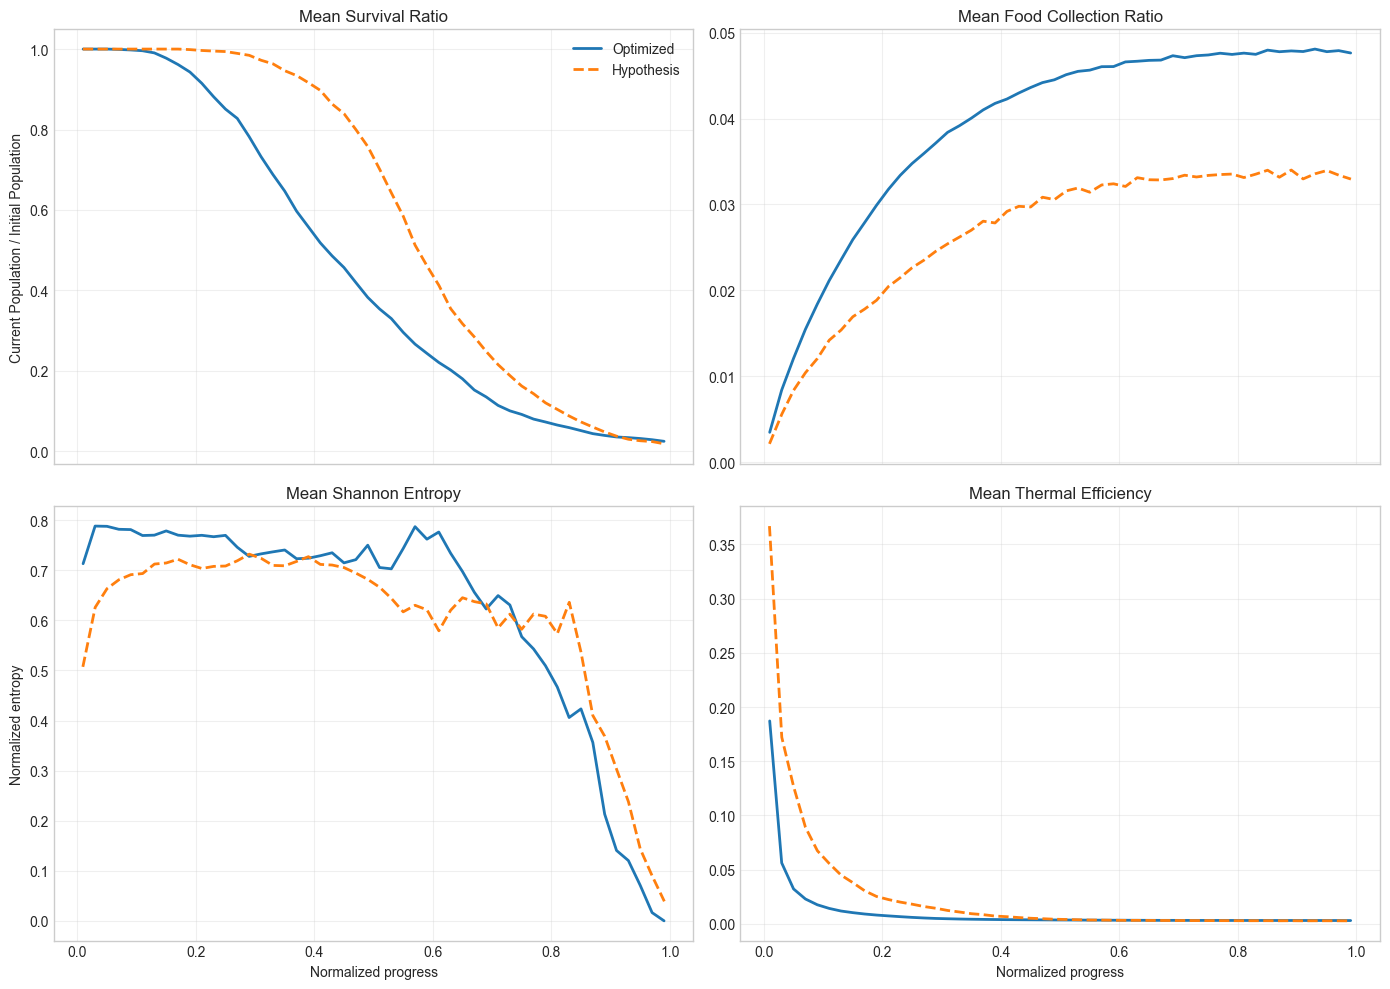

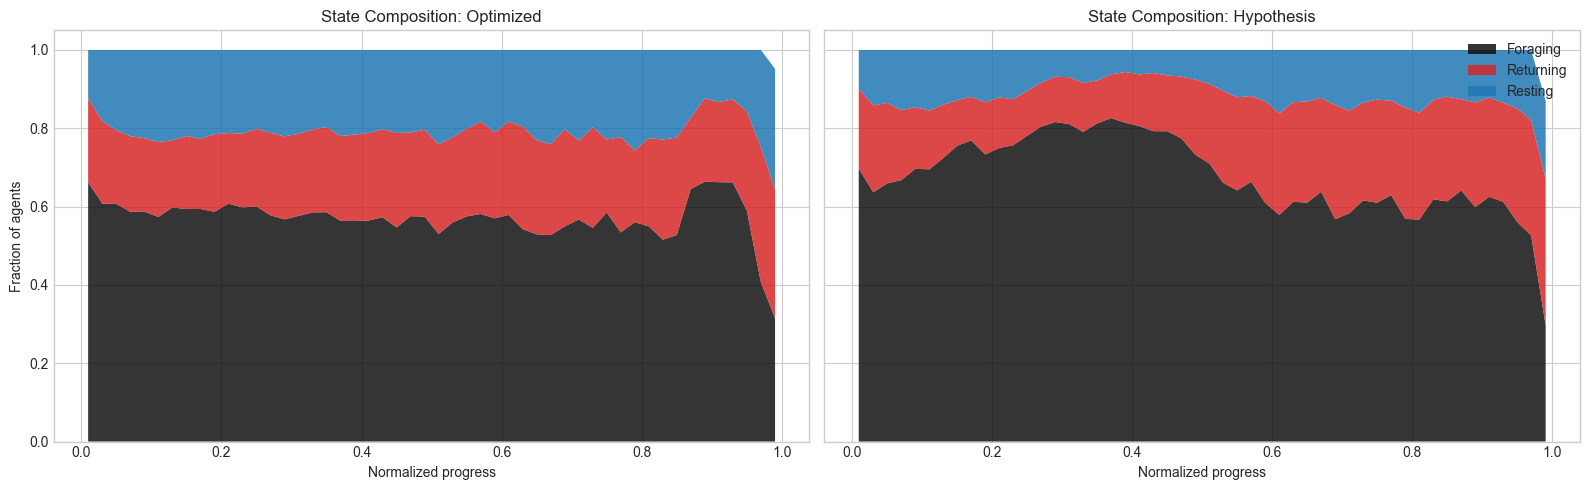

In [ ]:
def process_mission_progression(df, dataset_name):
    print(f"--- Mission Progression: {dataset_name} ---")
    
    # Work on a copy to avoid SettingWithCopy warnings
    df = df.copy()
    
    # State identification
    df["is_foraging"] = (df["State"] == "FORAGING").astype(int)
    df["is_returning"] = (df["State"] == "RETURNING").astype(int)
    df["is_resting"] = (df["State"] == "RESTING").astype(int)
    df["has_food_int"] = df["Has Food"].fillna(False).astype(bool).astype(int)

    # 1. Step-level aggregations
    step_summary = (
        df.groupby(["RunId", "Step"], as_index=False)
        .agg(
            num_agents=("AgentID", "size"),
            alive=("Alive", "first"),
            total_food_collected=("Total Food Collected", "first"),
            remaining_food_units=("Remaining Food (Units)", "first"),
            resource_retrieval_rate=("Resource Retrieval Rate", "first"),
            load_gini=("Load Gini", "first"),
            cumulative_thermal_load=("Cumulative Thermal Load", "first"),
            shannon_entropy=("Shannon Entropy", "first"),
            thermal_efficiency=("Thermal Efficiency", "first"),
            mean_agent_energy=("Energy", "mean"),
            mean_agent_temperature=("Temperature", "mean"),
            mean_distance_to_nest=("Distance_to_Nest", "mean"),
            mean_lifetime_food_collected=("Lifetime Food Collected", "mean"),
            share_foraging=("is_foraging", "mean"),
            share_returning=("is_returning", "mean"),
            share_resting=("is_resting", "mean"),
            share_has_food=("has_food_int", "mean"),
        )
        .sort_values(["RunId", "Step"])
        .reset_index(drop=True)
    )
    
    initial_population = step_summary.groupby("RunId")["alive"].transform("max")
    step_summary["survival_ratio"] = step_summary["alive"] / initial_population
    
    step_summary["food_collection_ratio"] = step_summary["total_food_collected"] / (
        step_summary["total_food_collected"] + step_summary["remaining_food_units"].clip(lower=1.0)
    )
    
    step_summary["normalized_progress"] = step_summary["Step"] / step_summary.groupby("RunId")["Step"].transform("max")
    
    step_summary["phase"] = pd.cut(
        step_summary["normalized_progress"],
        bins=np.linspace(0.0, 1.0, 6),
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )

    phase_means = (
        step_summary.groupby("phase", observed=False)
        .agg(
            survival_ratio=("survival_ratio", "mean"),
            food_collection_ratio=("food_collection_ratio", "mean"),
            resource_retrieval_rate=("resource_retrieval_rate", "mean"),
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            mean_distance_to_nest=("mean_distance_to_nest", "mean"),
            shannon_entropy=("shannon_entropy", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
            load_gini=("load_gini", "mean"),
            share_foraging=("share_foraging", "mean"),
            share_returning=("share_returning", "mean"),
            share_resting=("share_resting", "mean"),
            share_has_food=("share_has_food", "mean"),
        )
        .reset_index()
    )

    progress_bins = np.linspace(0.0, 1.0, 51)
    step_summary["progress_bin"] = pd.cut(step_summary["normalized_progress"], bins=progress_bins, labels=False, include_lowest=True)
    
    progress_curves = (
        step_summary.dropna(subset=["progress_bin"])
        .groupby("progress_bin", observed=True)
        .agg(
            progress_center=("normalized_progress", "mean"),
            survival_ratio=("survival_ratio", "mean"),
            food_collection_ratio=("food_collection_ratio", "mean"),
            resource_retrieval_rate=("resource_retrieval_rate", "mean"),
            shannon_entropy=("shannon_entropy", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
            share_foraging=("share_foraging", "mean"),
            share_returning=("share_returning", "mean"),
            share_resting=("share_resting", "mean"),
        )
        .reset_index(drop=True)
    )

    # Summaries
    print(f"- Avg survival ratio: {step_summary['survival_ratio'].mean():.3f}")
    print(f"- Avg resource retrieval rate: {step_summary['resource_retrieval_rate'].mean():.3f}")
    print(f"- Avg Shannon entropy: {step_summary['shannon_entropy'].mean():.3f}")
    print(f"- Avg thermal efficiency: {step_summary['thermal_efficiency'].mean():.5f}")
    print()
    display(phase_means)
    print("\n" + "="*50 + "\n")
    
    return phase_means, progress_curves

phase_opt, prog_opt = process_mission_progression(optimized, "Optimized")
phase_hyp, prog_hyp = process_mission_progression(hypothesis, "Hypothesis")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Survival Ratio
axes[0, 0].plot(prog_opt["progress_center"], prog_opt["survival_ratio"], color="#1f77b4", linewidth=2, label="Optimized")
axes[0, 0].plot(prog_hyp["progress_center"], prog_hyp["survival_ratio"], color="#ff7f0e", linewidth=2, linestyle="--", label="Hypothesis")
axes[0, 0].set_title("Mean Survival Ratio")
axes[0, 0].set_ylabel("Current Population / Initial Population")
axes[0, 0].legend()

# Food Collection Ratio
axes[0, 1].plot(prog_opt["progress_center"], prog_opt["food_collection_ratio"], color="#1f77b4", linewidth=2)
axes[0, 1].plot(prog_hyp["progress_center"], prog_hyp["food_collection_ratio"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 1].set_title("Mean Food Collection Ratio")

# Shannon Entropy
axes[1, 0].plot(prog_opt["progress_center"], prog_opt["shannon_entropy"], color="#1f77b4", linewidth=2)
axes[1, 0].plot(prog_hyp["progress_center"], prog_hyp["shannon_entropy"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 0].set_title("Mean Shannon Entropy")
axes[1, 0].set_xlabel("Normalized progress")
axes[1, 0].set_ylabel("Normalized entropy")

# Thermal Efficiency
axes[1, 1].plot(prog_opt["progress_center"], prog_opt["thermal_efficiency"], color="#1f77b4", linewidth=2)
axes[1, 1].plot(prog_hyp["progress_center"], prog_hyp["thermal_efficiency"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 1].set_title("Mean Thermal Efficiency")
axes[1, 1].set_xlabel("Normalized progress")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

labels = ["Foraging", "Returning", "Resting"]
colors = ["#111111", "#d62728", "#1f77b4"]

# Optimized Stack
ax1.stackplot(
    prog_opt["progress_center"],
    prog_opt["share_foraging"], prog_opt["share_returning"], prog_opt["share_resting"],
    labels=labels, colors=colors, alpha=0.85
)
ax1.set_title("State Composition: Optimized")
ax1.set_xlabel("Normalized progress")
ax1.set_ylabel("Fraction of agents")

# Hypothesis Stack
ax2.stackplot(
    prog_hyp["progress_center"],
    prog_hyp["share_foraging"], prog_hyp["share_returning"], prog_hyp["share_resting"],
    labels=labels, colors=colors, alpha=0.85
)
ax2.set_title("State Composition: Hypothesis")
ax2.set_xlabel("Normalized progress")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

The plots reveal a clear difference in labour allocation between the two groups. The Hypothesis configuration follows a highly aggressive strategy, with agents spending roughly (70%-80%) of their time in the FORAGING state during the first half of the simulation. This produces strong early-stage performance, particularly in food collection and thermal efficiency during the first (20%) of progression, but it also creates a rapid accumulation of “thermal debt.”

The Optimized group instead maintains a consistent resting buffer, with approximately (20%) of agents remaining in the RESTING state throughout the simulation. Although this lowers the initial collection rate, it functions as an effective thermal regulation mechanism. Since the cool_down() function in Agent.py is only activated during RESTING, the Optimized parameters prevent the widespread overheating observed in the Hypothesis group.

The Shannon Entropy results further support this interpretation. The Optimized swarm maintains a higher and more stable entropy value of approximately (0.75), compared to around (0.70) for the Hypothesis group. This suggests that the Optimized agents remain more evenly distributed across the environment, likely due to the tuning of pheromone_decay_rate and pheromone_follow_prob, which reduces excessive clustering around individual food sources and limits local competition.

The Thermal Efficiency results ((0.01042) for Optimized versus (0.02560) for Hypothesis) initially appear to favour the Hypothesis configuration. However, the temporal progression shows that this efficiency is concentrated entirely in the early stages of the simulation. After roughly (40%) progress, the Hypothesis efficiency collapses as agents begin dying or becoming thermally constrained. The Optimized group instead maintains a stable level of productivity over time, allowing it to collect nearly (50%) more total food despite a lower short-term efficiency.

Overall, the results demonstrate that sustained moderate efficiency is more effective than short-lived peak efficiency in environments with strict thermal constraints. The Optimized swarm succeeds by pacing its activity and using the nest not only for resource delivery, but also as a critical mechanism for thermal recovery.


## 4. Energy, Heat, and Fairness


--- Energy, Heat, and Fairness: Optimized ---
- Mean agent energy at 0-20%: 799.55
- Mean agent energy at 80-100%: 285.65
- Mean temperature at 0-20%: 34.92
- Mean temperature at 80-100%: 43.67
- Load Gini at 0-20%: 0.270
- Load Gini at 80-100%: 0.335

Final Run State Summary (Cleaned):


,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,1006.366667,507.373527,291.000000,576.750000,1023.000000,1280.500000,2563.000000
final_total_food_collected,30.0,362.100000,295.151083,16.000000,117.500000,363.000000,530.250000,1364.000000
final_mean_temperature,30.0,44.475000,2.985504,36.400000,43.450000,44.750000,46.500000,49.000000
final_load_gini,30.0,0.378401,0.117929,0.168328,0.316366,0.359311,0.470266,0.646875
final_thermal_efficiency,30.0,0.002248,0.001665,0.000133,0.000912,0.002064,0.003146,0.008133



--- Energy, Heat, and Fairness: Hypothesis ---
- Mean agent energy at 0-20%: 893.32
- Mean agent energy at 80-100%: 194.71
- Mean temperature at 0-20%: 32.80
- Mean temperature at 80-100%: 49.58
- Load Gini at 0-20%: 0.318
- Load Gini at 80-100%: 0.326

Final Run State Summary (Cleaned):


,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,360.500000,167.683764,201.000000,232.250000,292.000000,427.500000,817.000000
final_total_food_collected,30.0,227.566667,280.465830,9.000000,19.000000,129.500000,302.250000,1143.000000
final_mean_temperature,30.0,50.701667,2.417126,44.700000,49.500000,50.850000,52.800000,53.100000
final_load_gini,30.0,0.398314,0.233225,0.102345,0.198046,0.310523,0.662727,0.855556
final_thermal_efficiency,30.0,0.001917,0.001990,0.000087,0.000216,0.001457,0.002689,0.008251


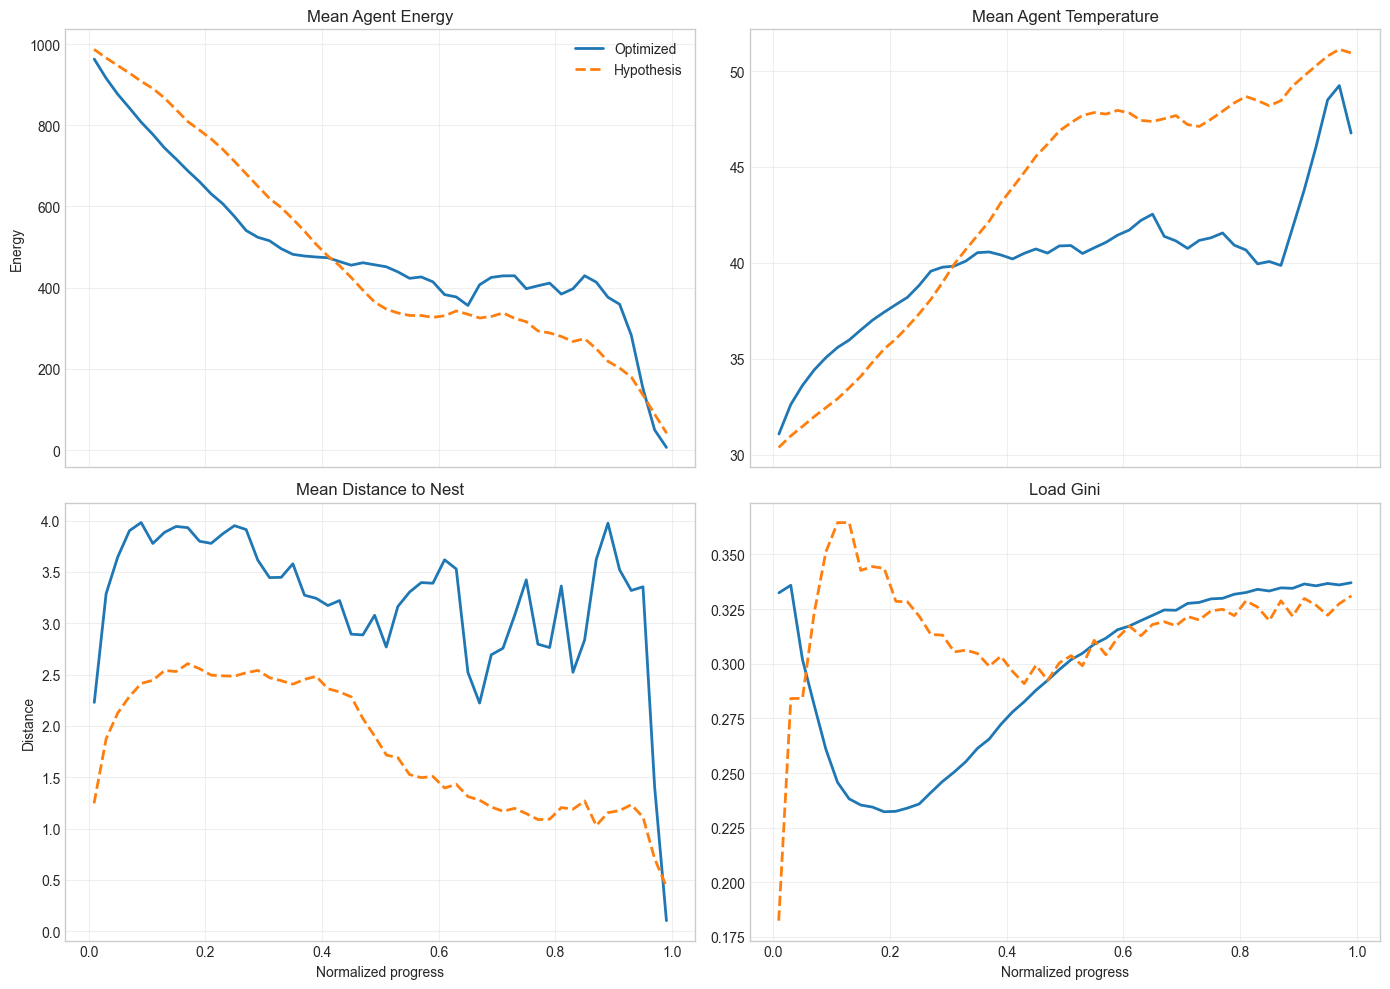

In [ ]:
def process_energy_heat_fairness(df, dataset_name):
    print(f"\n--- Energy, Heat, and Fairness: {dataset_name} ---")
    
    step_summary = (
        df.groupby(["RunId", "Step"], as_index=False)
        .agg(
            total_food_collected=("Total Food Collected", "first"),
            mean_agent_energy=("Energy", "mean"),
            mean_agent_temperature=("Temperature", "mean"),
            mean_distance_to_nest=("Distance_to_Nest", "mean"),
            load_gini=("Load Gini", "first"),
            thermal_efficiency=("Thermal Efficiency", "first"),
        )
        .sort_values(["RunId", "Step"])
        .reset_index(drop=True)
    )
    
    step_summary["normalized_progress"] = step_summary["Step"] / step_summary.groupby("RunId")["Step"].transform("max")
    
    step_summary["phase"] = pd.cut(
        step_summary["normalized_progress"],
        bins=np.linspace(0.0, 1.0, 6),
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )
    
    progress_bins = np.linspace(0.0, 1.0, 51)
    step_summary["progress_bin"] = pd.cut(step_summary["normalized_progress"], bins=progress_bins, labels=False, include_lowest=True)

    phase_means = (
        step_summary.groupby("phase", observed=False)
        .agg(
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            load_gini=("load_gini", "mean")
        )
        .reset_index()
    )

    print(f"- Mean agent energy at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'mean_agent_energy'].iloc[0]:.2f}")
    print(f"- Mean agent energy at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'mean_agent_energy'].iloc[0]:.2f}")
    print(f"- Mean temperature at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'mean_agent_temperature'].iloc[0]:.2f}")
    print(f"- Mean temperature at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'mean_agent_temperature'].iloc[0]:.2f}")
    print(f"- Load Gini at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'load_gini'].iloc[0]:.3f}")
    print(f"- Load Gini at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'load_gini'].iloc[0]:.3f}")

    energy_curves = (
        step_summary.dropna(subset=["progress_bin"])
        .groupby("progress_bin", observed=True)
        .agg(
            progress_center=("normalized_progress", "mean"),
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            mean_distance_to_nest=("mean_distance_to_nest", "mean"),
            load_gini=("load_gini", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
        )
        .reset_index(drop=True)
    )

    energy_temperature_run_summary = (
        step_summary.groupby("RunId", as_index=False)
        .agg(
            completed_steps=("Step", "max"),
            final_total_food_collected=("total_food_collected", "last"),
            final_mean_temperature=("mean_agent_temperature", "last"),
            final_load_gini=("load_gini", "last"),
            final_thermal_efficiency=("thermal_efficiency", "last"),
        )
    )
    
    print("\nFinal Run State Summary (Cleaned):")
    display(energy_temperature_run_summary.drop(columns=["RunId"]).describe().T)
    
    return energy_curves

curves_opt = process_energy_heat_fairness(optimized, "Optimized")
curves_hyp = process_energy_heat_fairness(hypothesis, "Hypothesis")


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Mean Agent Energy
axes[0, 0].plot(curves_opt["progress_center"], curves_opt["mean_agent_energy"], color="#1f77b4", linewidth=2, label="Optimized")
axes[0, 0].plot(curves_hyp["progress_center"], curves_hyp["mean_agent_energy"], color="#ff7f0e", linewidth=2, linestyle="--", label="Hypothesis")
axes[0, 0].set_title("Mean Agent Energy")
axes[0, 0].set_ylabel("Energy")
axes[0, 0].legend()

# Mean Agent Temperature
axes[0, 1].plot(curves_opt["progress_center"], curves_opt["mean_agent_temperature"], color="#1f77b4", linewidth=2)
axes[0, 1].plot(curves_hyp["progress_center"], curves_hyp["mean_agent_temperature"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 1].set_title("Mean Agent Temperature")

# Mean Distance to Nest
axes[1, 0].plot(curves_opt["progress_center"], curves_opt["mean_distance_to_nest"], color="#1f77b4", linewidth=2)
axes[1, 0].plot(curves_hyp["progress_center"], curves_hyp["mean_distance_to_nest"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 0].set_title("Mean Distance to Nest")
axes[1, 0].set_xlabel("Normalized progress")
axes[1, 0].set_ylabel("Distance")

# Load Gini
axes[1, 1].plot(curves_opt["progress_center"], curves_opt["load_gini"], color="#1f77b4", linewidth=2)
axes[1, 1].plot(curves_hyp["progress_center"], curves_hyp["load_gini"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 1].set_title("Load Gini")
axes[1, 1].set_xlabel("Normalized progress")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Mean Distance to Nest results reveal a counter-intuitive exploration strategy in the Optimized swarm. Agents in the Optimized configuration travel significantly further from the nest early in the simulation, reaching an average distance of approximately 4.0, compared to 2.5 in the Hypothesis group. This wider exploration radius explains the sharper initial decline in Mean Agent Energy observed in the Optimized curve, as agents effectively “invest” energy into broader environmental search.

This strategy produces a clear fairness advantage. The Load Gini coefficient for the Optimized group drops substantially during the first 20% of the mission, indicating a more equal distribution of workload and resource discovery. By spreading across a larger area, more agents are able to locate food sources simultaneously. In contrast, the Hypothesis agents remain clustered closer to the nest, increasing local competition and producing a higher and more unstable Gini coefficient (0.318 versus 0.270).

The thermal regulation results provide the strongest distinction between the two strategies. Despite their greater movement and exploration costs, the Optimized agents maintain a stable mean temperature between 40∘C and 43∘C. The Hypothesis group instead exhibits a runaway thermal trend, reaching a final mean temperature of 50.7^\circ C. Given that T_{crit} = 53.0^\circ C, this leaves the Hypothesis swarm operating with a dangerously small thermal margin of only 2.3^\circ C.

By comparison, the Optimized agents maintain a thermal safety buffer of approximately 8.6^\circ C, nearly four times larger than the Hypothesis group. This indicates that the Optuna-tuned state-switching behaviour, particularly earlier returns to the nest and more frequent resting periods, successfully prevents the large-scale thermal mortality responsible for 34.8% of deaths in the Hypothesis configuration.

Overall, the Optimized swarm follows a “global search” strategy in which higher early energy expenditure enables wider spatial coverage, improved workload distribution, and safer thermal regulation. The Hypothesis swarm instead adopts a “local sink” strategy, conserving energy initially by remaining near the nest, but ultimately suffering from overcrowding, overheating, and the systemic collapse observed in the survival analysis.

## 5. Agent-Level Work Distribution

--- Agent-Level Work Distribution: Optimized ---
- Fraction of agents that collected no food: 10.4%
- Mean food collected per agent: 9.05
- Median food collected per agent: 6.00
- Share of all collected food handled by the top 10% of agents: 33.3%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Food Collected,1200.0,9.0525,9.320075,0.0,2.0,6.0,13.0,22.0,29.0,82.0




--- Agent-Level Work Distribution: Hypothesis ---
- Fraction of agents that collected no food: 25.3%
- Mean food collected per agent: 4.55
- Median food collected per agent: 2.00
- Share of all collected food handled by the top 10% of agents: 41.8%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Food Collected,1500.0,4.551333,5.914052,0.0,0.0,2.0,6.0,11.0,18.05,34.0


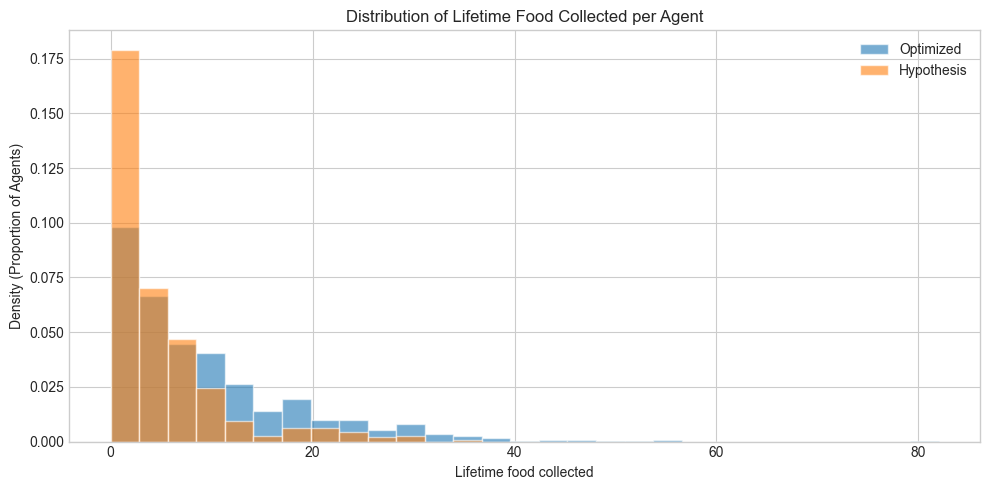

In [ ]:
def analyze_work_distribution(df, dataset_name):
    print(f"--- Agent-Level Work Distribution: {dataset_name} ---")

    agent_last_index = df.groupby(["RunId", "AgentID"])['Step'].idxmax()
    last_agent_rows = df.loc[agent_last_index].copy().reset_index(drop=True)


    agent_food = last_agent_rows["Lifetime Food Collected"].fillna(0).astype(float)

    food_summary = agent_food.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame().T
    food_summary.index = ["Lifetime Food Collected"]

    zero_food_fraction = float((agent_food <= 0).mean())

    food_sorted = np.sort(agent_food.to_numpy())
    if food_sorted.sum() > 0:
        top_10_start = int(np.floor(0.9 * len(food_sorted)))
        top_10_share = float(food_sorted[top_10_start:].sum() / food_sorted.sum())
    else:
        top_10_share = 0.0

    print(f"- Fraction of agents that collected no food: {zero_food_fraction:.1%}")
    print(f"- Mean food collected per agent: {agent_food.mean():.2f}")
    print(f"- Median food collected per agent: {agent_food.median():.2f}")
    print(f"- Share of all collected food handled by the top 10% of agents: {top_10_share:.1%}")
    print()
    display(food_summary)
    print("\n" + "="*50 + "\n")

    return agent_food

food_opt = analyze_work_distribution(optimized, "Optimized")
food_hyp = analyze_work_distribution(hypothesis, "Hypothesis")

fig, ax = plt.subplots(figsize=(10, 5))

min_food = min(food_opt.min(), food_hyp.min())
max_food = max(food_opt.max(), food_hyp.max())
shared_bins = np.linspace(min_food, max_food, 30) 

ax.hist(food_opt, bins=shared_bins, alpha=0.6, label="Optimized", density=True, color="#1f77b4", edgecolor="white")
ax.hist(food_hyp, bins=shared_bins, alpha=0.6, label="Hypothesis", density=True, color="#ff7f0e", edgecolor="white")

ax.set_title("Distribution of Lifetime Food Collected per Agent")
ax.set_xlabel("Lifetime food collected")
ax.set_ylabel("Density (Proportion of Agents)")
ax.legend()

plt.tight_layout()
plt.show()

--- Agent-Level Radial Movement: Optimized ---
- Mean radial distance per agent: 315.5
- Median radial distance per agent: 260.0
- Share of all radial movement done by the top 10% of agents: 22.7%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Radial Distance,1200.0,315.468333,180.296616,99.0,178.0,260.0,402.0,546.2,650.3,1714.0




--- Agent-Level Radial Movement: Hypothesis ---
- Mean radial distance per agent: 197.0
- Median radial distance per agent: 170.0
- Share of all radial movement done by the top 10% of agents: 20.9%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Radial Distance,1500.0,197.039333,92.23648,78.0,134.0,170.0,230.0,324.0,382.1,734.0


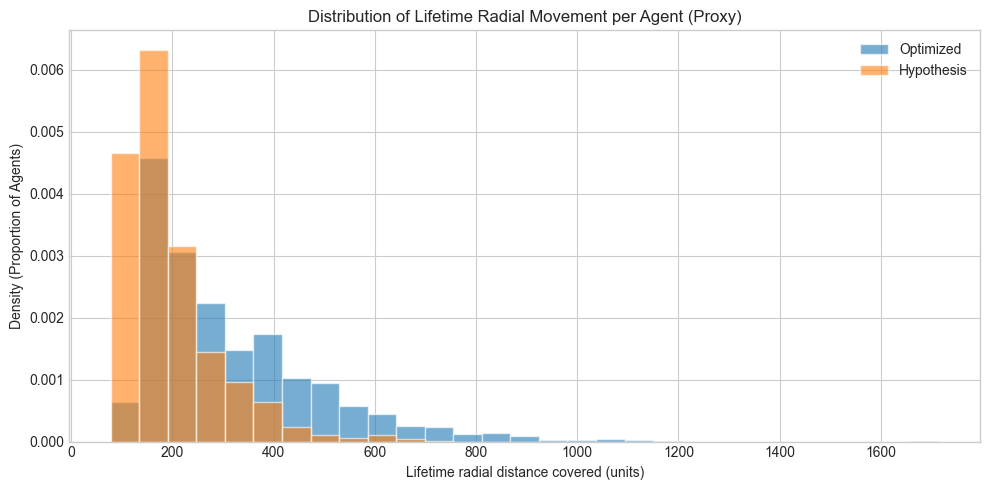

In [7]:
def analyze_radial_distance(df, dataset_name):
    print(f"--- Agent-Level Radial Movement: {dataset_name} ---")
    df_sorted = df.sort_values(["RunId", "AgentID", "Step"]).copy()
    df_sorted["step_radial_dist"] = df_sorted.groupby(["RunId", "AgentID"])["Distance_to_Nest"].diff().abs().fillna(0)

    agent_radial_distance = df_sorted.groupby(["RunId", "AgentID"])["step_radial_dist"].sum()

    dist_summary = agent_radial_distance.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame().T
    dist_summary.index = ["Lifetime Radial Distance"]

    dist_sorted = np.sort(agent_radial_distance.to_numpy())
    if dist_sorted.sum() > 0:
        top_10_start = int(np.floor(0.9 * len(dist_sorted)))
        top_10_share = float(dist_sorted[top_10_start:].sum() / dist_sorted.sum())
    else:
        top_10_share = 0.0

    print(f"- Mean radial distance per agent: {agent_radial_distance.mean():,.1f}")
    print(f"- Median radial distance per agent: {agent_radial_distance.median():,.1f}")
    print(f"- Share of all radial movement done by the top 10% of agents: {top_10_share:.1%}")
    print()
    display(dist_summary)
    print("\n" + "="*50 + "\n")

    return agent_radial_distance

dist_opt = analyze_radial_distance(optimized, "Optimized")
dist_hyp = analyze_radial_distance(hypothesis, "Hypothesis")


fig, ax = plt.subplots(figsize=(10, 5))

min_dist = min(dist_opt.min(), dist_hyp.min())
max_dist = max(dist_opt.max(), dist_hyp.max())
shared_bins = np.linspace(min_dist, max_dist, 30)

# Overlaid histograms
ax.hist(dist_opt, bins=shared_bins, alpha=0.6, label="Optimized", density=True, color="#1f77b4", edgecolor="white")
ax.hist(dist_hyp, bins=shared_bins, alpha=0.6, label="Hypothesis", density=True, color="#ff7f0e", edgecolor="white")

ax.set_title("Distribution of Lifetime Radial Movement per Agent (Proxy)")
ax.set_xlabel("Lifetime radial distance covered (units)")
ax.set_ylabel("Density (Proportion of Agents)")
ax.legend()

plt.tight_layout()
plt.show()

The agent-level work distribution shows that the Optimized configuration creates a more inclusive and balanced swarm economy. Only (10.4%) of Optimized agents failed to collect food, compared to (25.3%) in the Hypothesis group, suggesting that the tuned pheromone-following parameters produce a more accessible information landscape for all agents. Task inequality was also lower in the Optimized swarm, where the top (10%) of agents collected (33.3%) of total food, compared to (41.8%) in the Hypothesis configuration.

The radial movement analysis further shows that Optimized agents were more persistent and mobile, covering an average distance of (315.5) units versus (197.0) in the Hypothesis group. The much longer movement tail observed in the Optimized population confirms that improved thermal regulation allowed agents to sustain exploration for longer periods, directly contributing to higher individual productivity and greater overall food collection.